# Is ICE's rookie-attrition problem happening anywhere else?

The sibling `icehires` repo found that ICE's 2025 hiring surge came with unusually fast turnover
among the enforcement officers hired into it -- more than a quarter gone before their first year is
up. Two questions follow from that: is this an ICE-only story, and is there a cheap, general-purpose
way to check hundreds of other agencies for the same pattern without hand-building a full
cohort-tracking analysis for each one?

This notebook is as much about the method as the answer, because the obvious first attempt at that
method breaks in two different ways before it works. Both breakages, and the fixes, are shown below --
they're not a footnote, they're most of the reason to trust the final numbers.

In [1]:
import sys; sys.path.insert(0, "src")
import lib
import pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mtick, matplotlib.dates as mdates
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 30)

def show(df, pct=(), index=False, na_rep="—"):
    fmt = {}
    for c in df.columns:
        col = df[c]
        if c in pct:
            fmt[c] = lambda v: "" if pd.isna(v) else f"{v:,.1f}%"
        elif pd.api.types.is_numeric_dtype(col):
            s = col.dropna()
            whole = len(s) > 0 and bool((s == s.round()).all())
            fmt[c] = (lambda v: "" if pd.isna(v) else f"{int(round(v)):,}") if whole \
                     else (lambda v: "" if pd.isna(v) else f"{v:,.1f}")
    sty = df.style.format(fmt, na_rep=na_rep)
    return sty if index else sty.hide(axis="index")

def ym_label(ym):
    return pd.to_datetime(str(ym), format="%Y%m").strftime("%b %Y")

C_MAIN, C_ALT, C_MUTED = "#2166ac", "#c0392b", "#8a8f98"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.bbox": "tight", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#bbbbbb",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelcolor": "#444", "axes.labelsize": 10, "xtick.color": "#444", "ytick.color": "#444",
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#dddddd", "grid.linewidth": 0.7,
    "legend.frameon": False,
})
def date_x(ax):
    loc = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

con = lib.con()
def q(sql): return con.execute(sql).df()
def scalar(sql): return con.execute(sql).fetchone()[0]
dbl = lib.dbl

print(f"Anchor window: {ym_label(lib.POST_START)} - {ym_label(lib.POST_END)}, "
      f"vs. equal-length prior window {ym_label(lib.PRIOR_START)} - {ym_label(lib.PRIOR_END)}")

Anchor window: Sep 2025 - Jul 2026, vs. equal-length prior window Sep 2024 - Jul 2025


## 1. Method: does `length_of_service_years` actually mean "just hired"?

OPM/EHRI has no person IDs, so you can't directly ask "are the people hired in month X still here
in month Y." But every accession, separation, and employment record carries
`length_of_service_years` -- a continuous field, not a pre-binned bracket. If it's trustworthy, a
separation record showing a low value is a real signal that whoever left had joined recently.

**Check 1: does it actually behave that way?** Pull every FBI Special Agent record coded `NEW HIRE`
and look at `length_of_service_years` at the moment of hire -- it should be ~0.

In [2]:
val = q(f"""
    SELECT
      SUM(n) AS total,
      SUM(CASE WHEN {dbl('length_of_service_years')} = 0 THEN n ELSE 0 END) AS exactly_zero,
      SUM(CASE WHEN {dbl('length_of_service_years')} < 1 THEN n ELSE 0 END) AS under_1yr,
      SUM(CASE WHEN {dbl('length_of_service_years')} >= 5 THEN n ELSE 0 END) AS five_plus_yrs
    FROM '{lib.FBI_ACC}' WHERE accession_category LIKE 'NEW HIRE%'
""").iloc[0]
show(pd.DataFrame([
    {"Check": "Exactly 0 years", "People": val.exactly_zero, "Share": 100*val.exactly_zero/val.total},
    {"Check": "Under 1 year", "People": val.under_1yr, "Share": 100*val.under_1yr/val.total},
    {"Check": "5+ years (lateral/rehire, prior federal credit)", "People": val.five_plus_yrs, "Share": 100*val.five_plus_yrs/val.total},
]), pct=["Share"])

Check,People,Share
Exactly 0 years,"4,238",84.6%
Under 1 year,"4,285",85.5%
"5+ years (lateral/rehire, prior federal credit)",402,8.0%


85% cluster under a year, confirming the field works. The ~8-15% with 5+ years are lateral
entries carrying prior federal service credit -- still genuinely new to the job, just not to the
government. Good enough to build on.

**First attempt, and failure #1: seasonal noise.** The obvious plan -- trailing-12-month
separations of under-1-year people, divided by trailing-12-month average headcount of that same
group, for every agency -- sounds reasonable. Try it with no other filtering.

In [3]:
naive_hc = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{lib.SCREEN_NAIVE_EMP}' GROUP BY 1,2,3")
naive_sep = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{lib.SCREEN_NAIVE_SEP}' GROUP BY 1,2,3")

def ttm_rate(hc, sep, min_hc=20):
    df = hc.merge(sep, on=["ym","agency_subelement","agency_subelement_code"], how="outer", suffixes=("_hc","_sep"))
    df[["n_hc","n_sep"]] = df[["n_hc","n_sep"]].fillna(0)
    rows = []
    for code_, g in df.sort_values("ym").groupby("agency_subelement_code"):
        g = g.set_index("ym")
        if len(g) < 24: continue
        hc_ttm, sep_ttm = g["n_hc"].rolling(12).mean(), g["n_sep"].rolling(12).sum()
        rate = (100*sep_ttm/hc_ttm).dropna()
        if len(rate) < 13 or hc_ttm.iloc[-1] < min_hc: continue
        rows.append({"code": code_, "agency": g["agency_subelement"].iloc[-1],
                     "hc_latest": round(hc_ttm.iloc[-1]), "rate_latest": round(rate.iloc[-1],1)})
    return pd.DataFrame(rows)

naive_ranked = ttm_rate(naive_hc, naive_sep)
print(f"{len(naive_ranked)} agencies ranked.\n")
display(show(naive_ranked.sort_values("rate_latest", ascending=False).head(8)
     .rename(columns={"code":"Code","agency":"Agency","hc_latest":"Under-1yr headcount","rate_latest":"TTM rate"}),
     pct=["TTM rate"]))
print(f"\nICE's rank on this list: {(naive_ranked.sort_values('rate_latest', ascending=False).reset_index(drop=True).code == 'HSBB').idxmax() + 1 if 'HSBB' in naive_ranked.code.values else 'not in the ranked set'} of {len(naive_ranked)}")

197 agencies ranked.



Code,Agency,Under-1yr headcount,TTM rate
ARSE,HQDA FIELD OPERATING AGENCIES AND STAFF SUPPORT AGENCIES AND STAFF SUPPORT AGENCIES,41,318.4%
GS03,PUBLIC BUILDINGS SERVICE,25,275.1%
AG16,NATURAL RESOURCES CONSERVATION SERVICE,117,269.5%
DD48,DEFENSE HUMAN RESOURCES ACTIVITY,27,240.7%
IN05,BUREAU OF LAND MANAGEMENT,281,223.5%
GS30,FEDERAL ACQUISITION SERVICE,24,175.5%
NF00,NATIONAL SCIENCE FOUNDATION,27,161.5%
IN10,NATIONAL PARK SERVICE,"1,682",152.8%



ICE's rank on this list: 51 of 197


Useless. Forest Service, National Park Service, Bureau of Land Management -- these are
seasonal/term-hire-heavy workforces where the under-1-year population naturally cycles through in a
few months every year, so a >100% annualized rate just means "normal seasonal turnover." ICE doesn't
even crack the top of this list -- it's buried under the noise. **The naive version doesn't just give
a few wrong answers, it hides the real one.**

**Fix #1: restrict to permanent appointments** (`appointment_type LIKE '%PERMANENT%' AND NOT LIKE
'%NONPERMANENT%'`), which drops the seasonal/term noise.

In [4]:
perm_hc = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{lib.SCREEN_PERM_EMP}' GROUP BY 1,2,3")
perm_sep = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{lib.SCREEN_PERM_SEP}' GROUP BY 1,2,3")
perm_ranked = ttm_rate(perm_hc, perm_sep)
print(f"{len(perm_ranked)} agencies ranked (permanent only).")
print(perm_ranked[perm_ranked.code=="HSBB"].to_string(index=False))

172 agencies ranked (permanent only).
code                              agency  hc_latest  rate_latest
HSBB IMMIGRATION AND CUSTOMS ENFORCEMENT       3837         40.6


Better -- ICE now shows a real elevated rate. But this is still a **stock-based** rate: the
denominator is however many people currently happen to have under a year of tenure. That denominator
mechanically collapses toward zero if an agency just stops hiring, which inflates the rate for reasons
that have nothing to do with people quitting -- **failure #2**. An agency that hired a lot last year
and nothing this year will show a huge "attrition rate" even with completely normal separation counts,
because there's almost no one left in the under-1-year pool to divide by.

**Fix #2: use actual hiring as the denominator, and match departures to the hiring vintage that
produced them.** For every separation record, back out an *implied hire month* (event month minus
tenure-at-departure) and only count it against a given hiring window if that implied hire month falls
inside the window. That's `lib.implied_hire_cohort()` -- the same logic `icehires` uses to track
ICE's surge cohort, generalized to run on any agency and any window without needing to know its
hiring history in advance.

The rest of this notebook uses that corrected method, anchored on **Sep 2025 - Jul 2026** -- the
post-inauguration window -- compared against the equal-length prior year, **Sep 2024 - Jul 2025**.

## 2. FBI: does the DRP exodus look like a hiring problem?

FBI had a real shock in 2025 -- leadership turnover and a large one-month separations spike. Worth
checking directly with the validated method: is that elevated turnover among recently hired agents
(a "standards slipped" story), or something else?

Sep 2025 -> Nov 2025: 13,224 -> 12,875 (349 people) in two months.


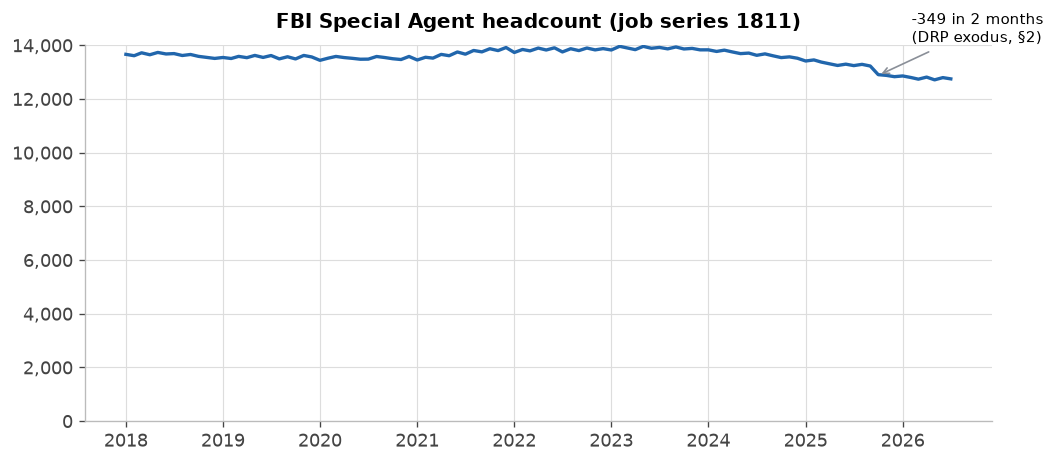

In [5]:
hc = q(f"SELECT ym, SUM(n) AS n FROM '{lib.FBI_EMP}' GROUP BY 1 ORDER BY 1")
hc["date"] = pd.to_datetime(hc.ym, format="%Y%m")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hc.date, hc.n, lw=2, color=C_MAIN)
ax.set_title("FBI Special Agent headcount (job series 1811)")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
date_x(ax)

drop_start = int(scalar(f"SELECT SUM(n) FROM '{lib.FBI_EMP}' WHERE ym='202509'"))
drop_end = int(scalar(f"SELECT SUM(n) FROM '{lib.FBI_EMP}' WHERE ym='202511'"))
drop_date = pd.to_datetime("202510", format="%Y%m")
ax.annotate(f"-{drop_start-drop_end:,} in 2 months\n(DRP exodus, \u00a72)", xy=(drop_date, drop_end),
            xytext=(20, 20), textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color=C_MUTED))
fig.tight_layout()
print(f"Sep 2025 -> Nov 2025: {drop_start:,} -> {drop_end:,} ({drop_start-drop_end:,} people) in two months.")


Under-1-year separations: 0-5/month, the whole period.


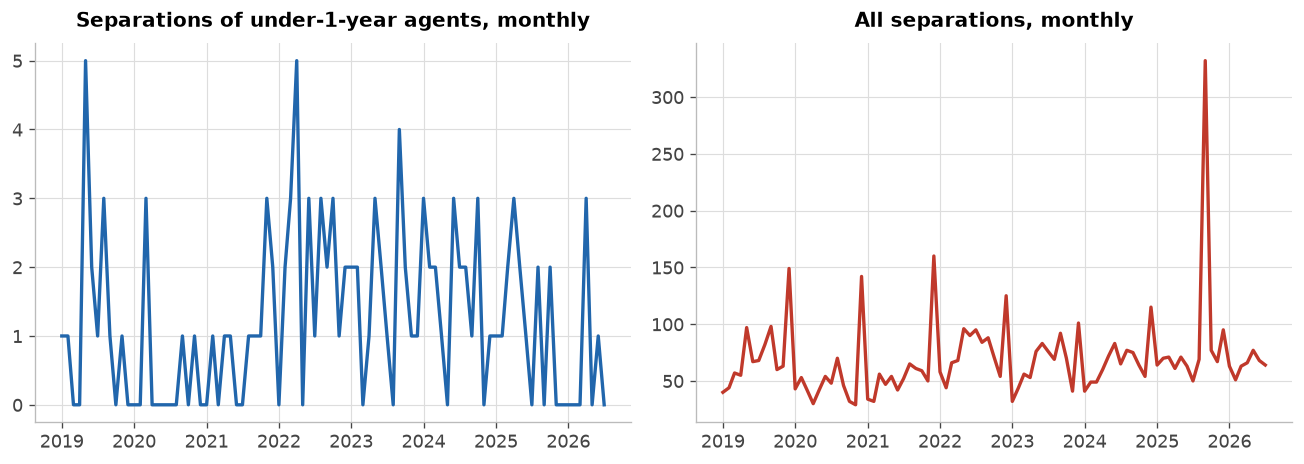

In [6]:
sep_tenure = q(f"""
    SELECT ym, SUM(CASE WHEN {dbl('length_of_service_years')} < 1 THEN n ELSE 0 END) AS under_1yr, SUM(n) AS total
    FROM '{lib.FBI_SEP}' WHERE ym >= '201901' GROUP BY 1 ORDER BY 1
""")
sep_tenure["date"] = pd.to_datetime(sep_tenure.ym, format="%Y%m")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(sep_tenure.date, sep_tenure.under_1yr, lw=2, color=C_MAIN)
axes[0].set_title("Separations of under-1-year agents, monthly")
axes[1].plot(sep_tenure.date, sep_tenure.total, lw=2, color=C_ALT)
axes[1].set_title("All separations, monthly")
for ax in axes: date_x(ax)
fig.tight_layout()
print(f"Under-1-year separations: {sep_tenure.under_1yr.min():.0f}-{sep_tenure.under_1yr.max():.0f}/month, the whole period.")

In [7]:
drp = q(f"""
    SELECT separation_category, drp_indicator, SUM(n) AS n FROM '{lib.FBI_SEP}'
    WHERE ym = '{lib.DRP_MONTH}' GROUP BY 1,2 ORDER BY n DESC
""")
display(show(drp.rename(columns={"separation_category":"Category","drp_indicator":"DRP-flagged","n":"People"})))
total = int(drp.n.sum()); drp_yes = int(drp.loc[drp.drp_indicator=="Y","n"].sum())
los = q(f"SELECT {dbl('length_of_service_years')} AS los, SUM(n) AS n FROM '{lib.FBI_SEP}' WHERE ym='{lib.DRP_MONTH}' GROUP BY 1")
mean_tenure = (los.los*los.n).sum()/los.n.sum()
share_20plus = 100*los.loc[los.los>=20,"n"].sum()/los.n.sum()
print(f"{ym_label(lib.DRP_MONTH)}: {total} separations, {drp_yes} ({100*drp_yes/total:.0f}%) DRP-flagged, "
      f"average tenure {mean_tenure:.1f} yrs, {share_20plus:.0f}% with 20+ years in.")

Category,DRP-flagged,People
RETIREMENT - VOLUNTARY,Y,189
QUIT,Y,56
RETIREMENT - VOLUNTARY,N,51
TERMINATION (EXPIRED APPT/OTHER),N,11
RETIREMENT - OTHER,N,6
QUIT,N,6
RETIREMENT - OTHER,Y,5
OTHER SEPARATION,N,5
RETIREMENT - EARLY OUT,N,2
TRANSFER OUT - INDIVIDUAL TRANSFER,N,1


Sep 2025: 332 separations, 250 (75%) DRP-flagged, average tenure 21.8 yrs, 78% with 20+ years in.


**No rookie-attrition signal at all.** Under-1-year departures sit at a handful a month straight
through the period. September's spike was a DRP-driven exodus of agents averaging ~22 years of
service, not new agents washing out -- a real shock, but not a hiring-standards story. Useful negative
result: the method doesn't just find problems, it correctly rules one out.

## 3. Is ICE the only one? A corrected, government-wide screen

Every agency subelement, every job series (deliberately not restricted to law enforcement), using
the fixed method from §1: hires and departures both counted within the same window, departures
attributed to their implied hire month, no reliance on a shrinking or growing headcount stock.

In [8]:
def cohort_table(sep_rawlos_path, acc_path, window_start, window_end, min_hires=30):
    sep_raw = q(f"SELECT * FROM '{sep_rawlos_path}'")
    cohort = lib.implied_hire_cohort(sep_raw, window_start, window_end)
    seps = cohort.groupby(["agency_subelement_code","agency_subelement"])["n"].sum().rename("seps")
    hires_df = q(f"SELECT ym, agency_subelement, agency_subelement_code, SUM(n) AS n FROM '{acc_path}' GROUP BY 1,2,3")
    hires = (hires_df[(hires_df.ym >= window_start) & (hires_df.ym <= window_end)]
             .groupby(["agency_subelement_code","agency_subelement"])["n"].sum().rename("hires"))
    out = pd.concat([hires, seps], axis=1).fillna(0).reset_index()
    out = out[out.hires >= min_hires]
    out["pct"] = 100*out.seps/out.hires
    return out

post = cohort_table(lib.SCREEN_PERM_SEP_RAWLOS, lib.SCREEN_PERM_ACC, lib.POST_START, lib.POST_END)
prior = cohort_table(lib.SCREEN_PERM_SEP_RAWLOS_PRIORYEAR, lib.SCREEN_PERM_ACC, lib.PRIOR_START, lib.PRIOR_END)

yoy = post.merge(prior, on=["agency_subelement_code","agency_subelement"], suffixes=("_post","_prior"), how="inner")
yoy["change_pp"] = yoy.pct_post - yoy.pct_prior
print(f"{len(yoy)} agencies with 30+ permanent new hires in both the post and prior windows.")

131 agencies with 30+ permanent new hires in both the post and prior windows.


In [9]:
top_change = yoy.sort_values("change_pp", ascending=False).head(10)
show(top_change[["agency_subelement_code","agency_subelement","hires_prior","hires_post","pct_prior","pct_post","change_pp"]]
     .rename(columns={"agency_subelement_code":"Code","agency_subelement":"Agency","hires_prior":"Hires (prior yr)",
                       "hires_post":"Hires (post-Sep’25)","pct_prior":"Exit % (prior yr)","pct_post":"Exit % (post-Sep’25)",
                       "change_pp":"Change (pp)"}), pct=["Exit % (prior yr)","Exit % (post-Sep’25)"])

Code,Agency,Hires (prior yr),Hires (post-Sep’25),Exit % (prior yr),Exit % (post-Sep’25),Change (pp)
HSBB,IMMIGRATION AND CUSTOMS ENFORCEMENT,"1,188","8,223",4.3%,17.5%,13.2
TR93,INTERNAL REVENUE SERVICE,"7,792","1,208",21.0%,28.9%,7.8
HSBE,FEDERAL LAW ENFORCEMENT TRAINING CENTERS,57,84,1.8%,8.3%,6.6
IN10,NATIONAL PARK SERVICE,713,673,5.6%,9.1%,3.5
DJ15,"BUREAU OF ALCOHOL, TOBACCO, FIREARMS, AND EXPLOSIVES",105,48,1.9%,4.2%,2.3
DJ06,DRUG ENFORCEMENT ADMINISTRATION,322,441,2.2%,4.3%,2.1
NV14,OFFICE OF NAVAL RESEARCH,98,33,4.1%,6.1%,2.0
IN06,INDIAN AFFAIRS,164,106,8.5%,10.4%,1.8
DD27,MISSILE DEFENSE AGENCY,200,51,3.5%,3.9%,0.4
DD82,NATIONAL RECONNAISSANCE OFFICE,90,66,1.1%,1.5%,0.4


Sorting by the raw post-2025 percentage would be misleading -- TSA's number looks alarming (~18%)
but TSA has *always* run around there (screener turnover is structurally high; not new). Defense
Commissary Agency's rate actually *improved*. **Sorted by the change instead, only two agencies stand
out with real hiring volume and a genuinely worsened rate: ICE (+13 points) and IRS (+8 points).**
Everything else on the full list is either small-sample noise or a wash.

## 4. What's going on at IRS?

Same drill-down `dhs_hiring_surge.ipynb` does for ICE: which job, and why.

In [10]:
by_series = q(f"""
    SELECT occupational_series_code,
           SUM(CASE WHEN ym BETWEEN '{lib.PRIOR_START}' AND '{lib.PRIOR_END}' THEN n ELSE 0 END) AS hires_prior,
           SUM(CASE WHEN ym >= '{lib.POST_START}' THEN n ELSE 0 END) AS hires_post
    FROM '{lib.IRS_ACC}' GROUP BY 1 ORDER BY hires_prior DESC LIMIT 8
""")
show(by_series.rename(columns={"occupational_series_code":"Series","hires_prior":"Hires (prior yr)","hires_post":"Hires (post-Sep’25)"}))

Series,Hires (prior yr),Hires (post-Sep’25)
0962,"2,435","1,108"
0512,"1,402",2
0592,"1,254",0
0303,866,0
2210,404,1
1169,201,0
1811,167,82
1102,89,0


IRS essentially froze hiring everywhere -- Revenue Agents, Tax Examiners, clerical, IT -- **except
Contact Representatives** (call-center/taxpayer-service reps, series 0962), which is 92% of all IRS
hiring since September. The government-wide 28.9% number is, almost entirely, a Contact Representative
story.

In [11]:
sep_raw = q(f"SELECT * FROM '{lib.IRS_SEP}' WHERE occupational_series_code='0962'")
cohort = lib.implied_hire_cohort(sep_raw, lib.POST_START, lib.POST_END)
hires_0962 = int(scalar(f"SELECT SUM(n) FROM '{lib.IRS_ACC}' WHERE occupational_series_code='0962' AND ym >= '{lib.POST_START}'"))
print(f"0962 hires since Sep'25: {hires_0962:,}")
print(f"0962 cohort departures so far: {int(cohort.n.sum()):,}  ({100*cohort.n.sum()/hires_0962:.1f}%)")

why = cohort.groupby(["separation_category","drp_indicator"])["n"].sum().reset_index().sort_values("n", ascending=False)
display(show(why.rename(columns={"separation_category":"Reason","drp_indicator":"DRP-flagged","n":"People"})))

0962 hires since Sep'25: 1,108
0962 cohort departures so far: 333  (30.1%)


Reason,DRP-flagged,People
QUIT,N,293
TERMINATION (EXPIRED APPT/OTHER),N,31
OTHER SEPARATION,N,6
TRANSFER OUT - INDIVIDUAL TRANSFER,N,3


30% gone, 88% of it a plain voluntary quit (not DRP, not a firing). Worth checking against
history before calling this new -- both whether the rate itself is unusual, and whether it's part
of a longer-running trend.

**Is any of this actually unusual for this job?** Contact Representative is a call-center role
with a reputation for high turnover. Check the full 2019-2026 history.

In [12]:
acc_hist = q(f"SELECT ym, n FROM '{lib.IRS_0962_ACC_HIST}'")
sep_hist = q(f"SELECT ym, length_of_service_years, separation_category, n FROM '{lib.IRS_0962_SEP_HIST}'")

windows = [("2019-20","201909","202007"), ("2020-21","202009","202107"),
           ("2021-22","202109","202207"), ("2022-23","202209","202307"),
           ("2023-24","202309","202407"), ("2024-25","202409","202507"),
           ("2025-26","202509","202607")]
rows = []
for label, s, e in windows:
    hires = acc_hist[(acc_hist.ym>=s)&(acc_hist.ym<=e)].n.sum()
    if hires == 0: continue
    c = lib.implied_hire_cohort(sep_hist, s, e)
    quits = c[c.separation_category=="QUIT"].n.sum()
    c2mo = c[(c.los*12).round() <= 2]
    rows.append({"Hiring window": label, "Hires": hires, "Left by window end": int(c.n.sum()),
                 "Exit %": round(100*c.n.sum()/hires,1), "Quit %": round(100*quits/hires,1),
                 "Left within 0-2mo": int(c2mo.n.sum()), "Quick-quit %": round(100*c2mo.n.sum()/hires,1)})
hist_df = pd.DataFrame(rows)
display(show(hist_df, pct=["Exit %","Quit %","Quick-quit %"]))

Hiring window,Hires,Left by window end,Exit %,Quit %,Left within 0-2mo,Quick-quit %
2019-20,"3,018",511,16.9%,14.1%,275,9.1%
2020-21,"4,032",880,21.8%,19.6%,326,8.1%
2021-22,"5,623","1,698",30.2%,27.7%,786,14.0%
2022-23,"7,218","1,560",21.6%,19.6%,813,11.3%
2023-24,"5,240",637,12.2%,10.7%,335,6.4%
2024-25,"2,435",465,19.1%,16.6%,207,8.5%
2025-26,"1,108",333,30.1%,26.4%,157,14.2%


**The headline: IRS Contact Representatives -- job series 0962, the phone-line taxpayer-service
reps who answer IRS's main call center -- are leaving faster, in a workforce that's been shrinking
for years, and IRS isn't replacing them.** None of those three is a record-breaker on its own:
today's exit rate matches a 2021-22 pandemic-era peak, workforces shrink sometimes, hiring freezes
happen. What makes this worth flagging is that all three are true **at the same time, right now**:

- **Leaving faster:** the share of new 0962 hires gone within 2 months has climbed for three
  straight years -- 6.4% (2023-24) -> 8.5% (2024-25) -> 14.2% (2025-26) -- back up to the 2021-22
  peak (14.0%), not a new record but a real, sustained acceleration.
- **A shrinking workforce:** total 0962 headcount peaked at 25,221 in December 2024 and has fallen
  28% (7,076 people) to 18,145 by July 2026.
- **Not being replaced:** net change in 0962 headcount has been negative in 10 of the last 11
  months -- IRS is losing people faster than it's hiring them for this job, every month, right now.

Headcount peaked at 25,221 (Dec 2024), now 18,145 (Jul 2026) -- down 28.1%.
10 of the last 11 months were net headcount losses for 0962.


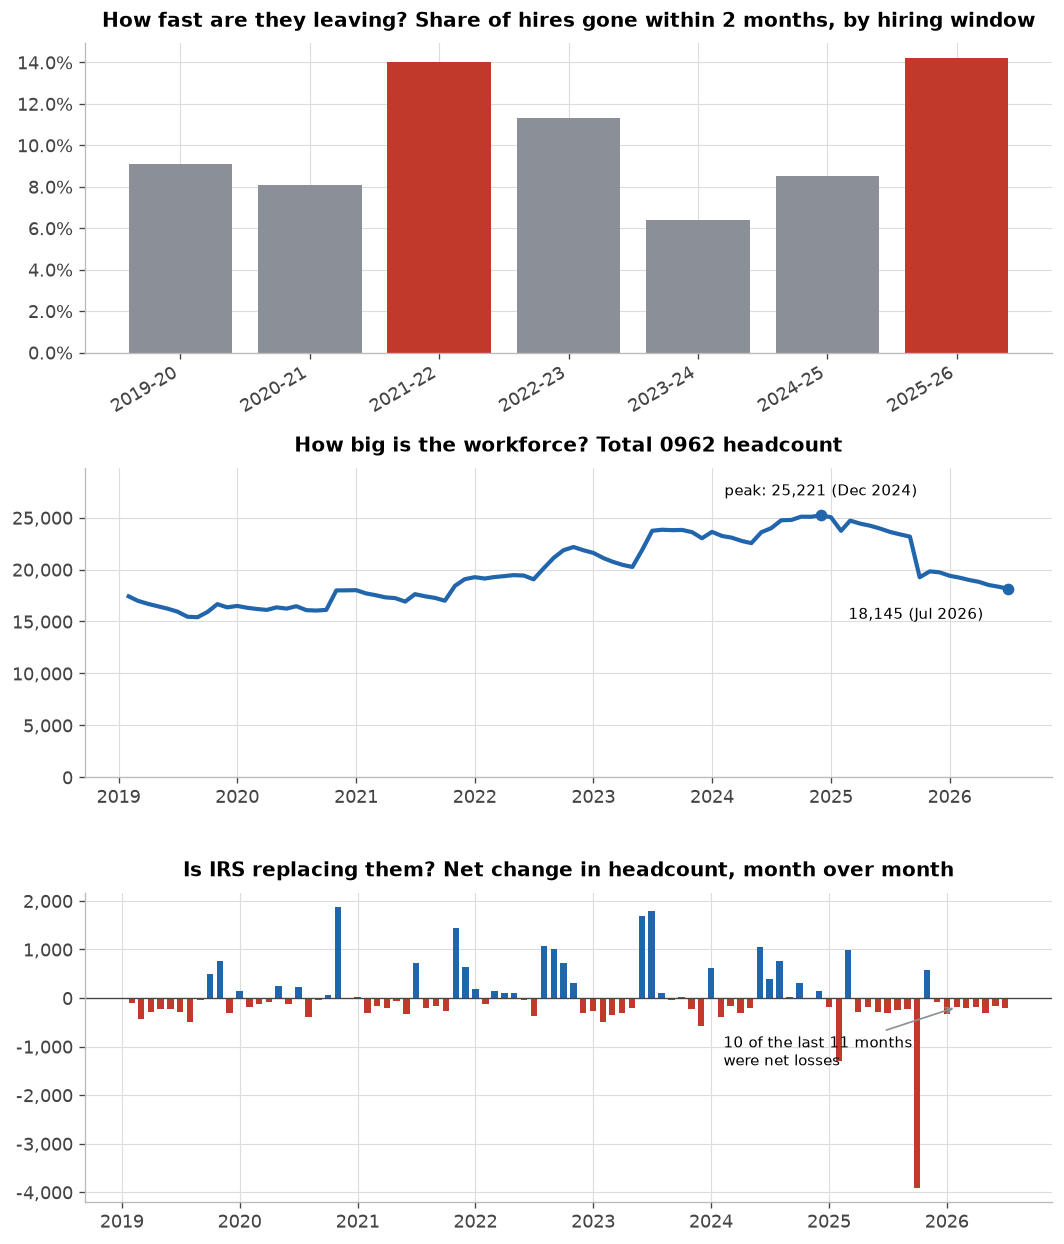

In [13]:
# The hero chart: three panels, one image, the whole "not being replaced" story in one
# place. Top -- quit speed by hiring-window-year, full history (not a new record, but a
# real recent climb). Middle -- total headcount over time (the role itself, shrinking).
# Bottom -- net change in headcount, month over month (the mechanism: is IRS actually
# replacing departures, or not).
emp_all = q(f"SELECT ym, {dbl('length_of_service_years')} AS los, n FROM '{lib.IRS_0962_EMP_HIST}'")
monthly = emp_all.groupby("ym")["n"].sum().reset_index()
monthly["date"] = pd.to_datetime(monthly.ym, format="%Y%m")
monthly["net_change"] = monthly.n.diff()
monthly = monthly[monthly.ym >= "201902"]

fig, (ax_speed, ax_level, ax_net) = plt.subplots(3, 1, figsize=(9, 10.5))

x = range(len(hist_df))
colors_speed = [C_ALT if w.startswith(("2021","2025")) else C_MUTED for w in hist_df["Hiring window"]]
ax_speed.bar(x, hist_df["Quick-quit %"], color=colors_speed)
ax_speed.set_xticks(list(x)); ax_speed.set_xticklabels(hist_df["Hiring window"], rotation=30, ha="right")
ax_speed.yaxis.set_major_formatter(mtick.PercentFormatter())
ax_speed.set_title("How fast are they leaving? Share of hires gone within 2 months, by hiring window")

ax_level.plot(monthly.date, monthly.n, lw=2.5, color=C_MAIN)
ax_level.set_ylim(0, monthly.n.max() * 1.18)
ax_level.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax_level.set_title("How big is the workforce? Total 0962 headcount")
date_x(ax_level)
peak = monthly.loc[monthly.n.idxmax()]
latest = monthly.iloc[-1]
ax_level.plot([peak.date, latest.date], [peak.n, latest.n], "o", color=C_MAIN, ms=6, zorder=5)
ax_level.annotate(f"peak: {peak.n:,.0f} ({ym_label(peak.ym)})", xy=(peak.date, peak.n), xytext=(0, 12),
                   textcoords="offset points", ha="center", fontsize=9)
ax_level.annotate(f"{latest.n:,.0f} ({ym_label(latest.ym)})", xy=(latest.date, latest.n), xytext=(-15, -18),
                   textcoords="offset points", ha="right", fontsize=9)

colors_net = [C_ALT if v < 0 else C_MAIN for v in monthly.net_change]
ax_net.bar(monthly.date, monthly.net_change, width=20, color=colors_net)
ax_net.axhline(0, color="#444", lw=0.8)
ax_net.set(title="Is IRS replacing them? Net change in headcount, month over month")
ax_net.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
date_x(ax_net)
months_negative = int((monthly.tail(11).net_change < 0).sum())
ax_net.annotate(f"{months_negative} of the last 11 months\nwere net losses", xy=(monthly.date.iloc[-6], monthly.net_change.iloc[-6]),
                xytext=(-140, -35), textcoords="offset points", fontsize=9,
                arrowprops=dict(arrowstyle="->", color=C_MUTED))

fig.tight_layout(); fig.savefig("figures/irs_0962_summary.png")
print(f"Headcount peaked at {peak.n:,.0f} ({ym_label(peak.ym)}), now {latest.n:,.0f} ({ym_label(latest.ym)}) "
      f"-- down {100*(peak.n-latest.n)/peak.n:.1f}%.")
print(f"{months_negative} of the last 11 months were net headcount losses for 0962.")

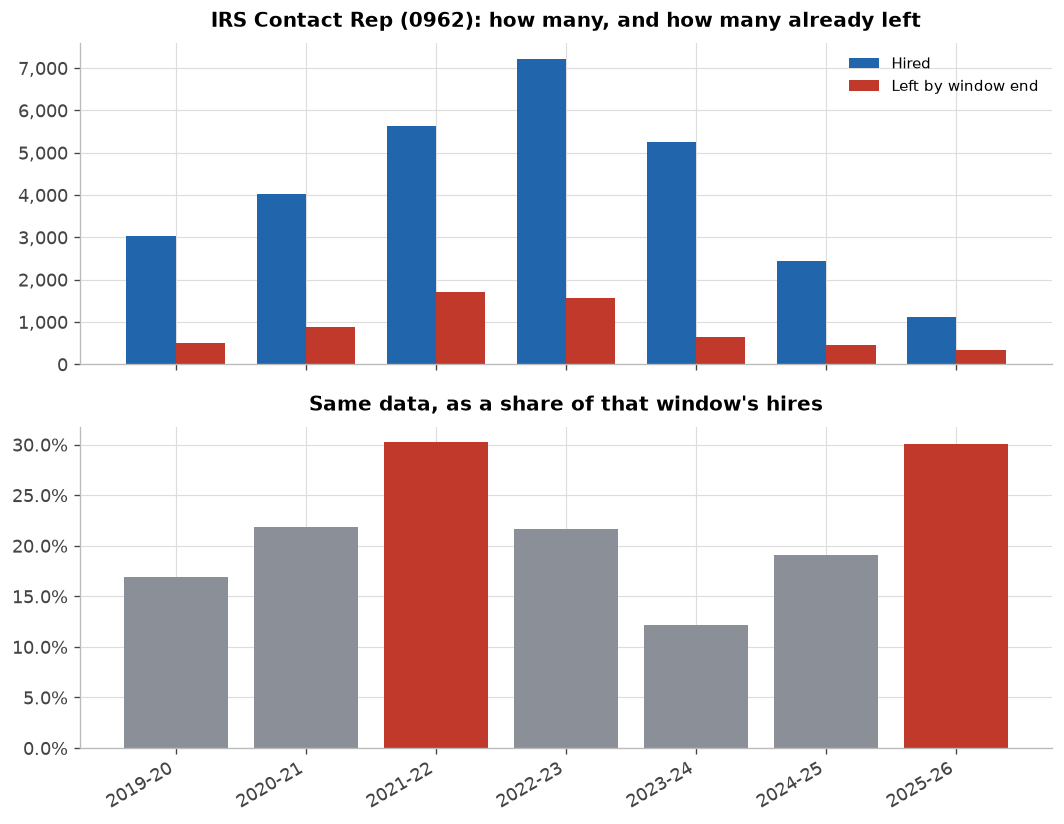

In [14]:
# One image, two panels: raw counts (is this actually a big cohort?) stacked on the
# rate (is the cohort's own attrition unusual?) -- neither panel alone tells the story.
fig, (ax_n, ax_pct) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
x = range(len(hist_df))
width = 0.38
ax_n.bar([i - width/2 for i in x], hist_df["Hires"], width=width, color=C_MAIN, label="Hired")
ax_n.bar([i + width/2 for i in x], hist_df["Left by window end"], width=width, color=C_ALT, label="Left by window end")
ax_n.set_title("IRS Contact Rep (0962): how many, and how many already left")
ax_n.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax_n.legend(fontsize=9)

colors = [C_ALT if w.startswith("2025") or w.startswith("2021") else C_MUTED for w in hist_df["Hiring window"]]
ax_pct.bar(x, hist_df["Exit %"], color=colors)
ax_pct.set_title("Same data, as a share of that window's hires")
ax_pct.yaxis.set_major_formatter(mtick.PercentFormatter())
ax_pct.set_xticks(list(x)); ax_pct.set_xticklabels(hist_df["Hiring window"], rotation=30, ha="right")

fig.tight_layout(); fig.savefig("figures/irs_0962_story.png")

One more angle on the same shrinkage: at the 2022 hiring peak, under-1-year employees were
**31.9%** of the whole 0962 workforce -- nearly a third brand new. Today that share is **3.1%**,
the lowest in the series. Not just fewer new hires in absolute terms, but a workforce that turned
from mostly-fresh to almost entirely veteran well before this window started.

## Where this leaves things

- **FBI**: no rookie-attrition signal. The 2025 shock was a DRP-driven exodus of senior agents, not
  new hires washing out -- the method correctly finds nothing here.
- **ICE**: confirmed independently (§3) from `dhs_hiring_surge.ipynb`'s cohort-tracking finding.
- **IRS**: a real, separate, comparably-sized finding -- concentrated almost entirely in Contact
  Representatives, ~30% of whom hired since September have already quit, mostly voluntarily and
  within a few months. Not a record rate on its own, but paired with historically low hiring for the
  first time.
- **Everyone else**: nothing else in government shows both real hiring volume and a genuinely
  worsened cohort-exit rate.
- **The method's limit**: this rules agencies in or out cheaply. For a headline number you'd publish
  (an ICE- or IRS-specific "X% have left" claim), the implied-hire-month correction is doing real
  work, but it is still an approximation from tenure-at-departure, not true person-level cohort
  tracking -- there are no person IDs in this data, full stop.